In [1]:
#Carga de datos
import pandas as pd
import json
import numpy as np
from Server_PD import download_dataframe_minio

from collections import Counter
import re

#Graficas
import seaborn as sns
import matplotlib.pyplot as plt
import isodate

from itertools import combinations
import ast

import analisisutils as utils


c:\Users\Usuario\Documents\U SEGUNDO AÑO\SEGUNDO CUATRI\PD1\c2526-R1\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


# Carga de datos

In [2]:
with open("Private/Claves.json", "r", encoding="utf-8") as archivo:
    claves = json.load(archivo)

claves["Url"] = claves["Url"].replace("https://", "").replace("http://", "").split("/")[0]
df = download_dataframe_minio("pd1", "grupo1/clean/union_dfs_20260309",claves=claves,file_format="parquet")
df.tail()

,ID,Titulo,Descripcion,Visualizaciones,Tags,Duracion,Fecha_publicacion,Titulo_canal,Subtitulos,Generos,Subgeneros,Made for kids,Rango_edad
31350,KEFuMgNoULU,Unbelievable 2026 Heartland Sundance XLT Fifth...,This 2026 Heartland Sundance XLT 24ML is a Fif...,0,"5053337, RVUSA",PT1M34S,2026-03-09 11:42:06+00:00,RVUSA,Kind: captions Language: en This 2026 H Heartl...,Autos & Vehicles,"Lifestyle (sociology), Vehicle",False,Adult
31351,i3RcDc9j-B0,Bargain Loving Brits In The Sun Daytime | Seri...,WATCH Bargain Loving Brits In The Sun Daytime ...,1457,"Bargain Loving Brits In The Sun, Bargain lovin...",PT42M40S,2026-03-08 16:00:55+00:00,Bargain Loving Brits,None,Entertainment,"Lifestyle (sociology), Television program, Tou...",False,Adult
31352,WJTrZVq98RM,"Good Morning America Full Broadcast — Sunday, ...",U.S. and Israeli forces launch a new wave of s...,100891,"ABC, ABC NEWS, GOOD MORNING AMERICA, p_cmsid=2...",PT31M57S,2026-03-08 17:00:45+00:00,ABC News,Kind: captions Language: en &gt;&gt; GOOD MORN...,News & Politics,"Politics, Society, Television program",False,Adult
31353,PEQa7dttgPA,How to Use an Oxy Soak for Grounding Product Care,Proper care plays an important role in maintai...,3,"earthshieldgrounding, earthing, grounding, fab...",PT58S,2026-03-09 00:58:16+00:00,EarthShield Grounding,Kind: captions Language: en Today I just wante...,People & Blogs,None,False,Adult
31354,pXW8_W1DF4c,Daily Prayer: The Lord Executes Justice for th...,"""The Lord executes justice for the oppressed a...",9,"Psalm 103:6-8, Prayer, daily prayer, Christian...",PT11M11S,2026-03-08 22:30:19+00:00,Light of Life,Kind: captions Language: en Daily Prayer The L...,Science & Technology,"Religion, Society",False,Adult


# Transformamos y añadimos columnas

In [3]:
#Duracion
def iso_a_minutos(iso_duration):
    """"
    Funcion que convierte la duracion a minutos
    """
    try:
        duracion = isodate.parse_duration(iso_duration)
        return duracion.total_seconds() / 60
    except:
        return 0

df['Duracion'] = df['Duracion'].apply(iso_a_minutos)

In [4]:
#Densidad de habla
df['Palabras_Por_Minuto'] = df.apply(utils.calcular_wpm, axis=1)
df['Palabras_Por_Minuto'] = round(df['Palabras_Por_Minuto'], 2)

# Limpiamos los datos

In [5]:
#CREAR CODIGO LIMPIEZA GENEROS

# Creamos un diccionario con un df por cada genero

In [6]:
diccionario_generos = utils.division_generos(df)
for clave in diccionario_generos:
    print(clave, ":", len(diccionario_generos[clave]))
    df = diccionario_generos[clave]
    df_Adult, df_Kids = utils.division_edad(df)
    print(f'    Adultos: {len(df_Adult)}')
    print(f'    Kids: {len(df_Kids)}')
#Los 0 se deben a que youtube Kids y youtube Movies

Film & Animation : 2666
    Adultos: 634
    Kids: 2032
Autos & Vehicles : 340
    Adultos: 241
    Kids: 99
Music : 2632
    Adultos: 1108
    Kids: 1524
Pets & Animals : 489
    Adultos: 154
    Kids: 335
Sports : 1241
    Adultos: 298
    Kids: 943
Short Movies : 0
    Adultos: 0
    Kids: 0
Travel & Events : 429
    Adultos: 318
    Kids: 111
Gaming : 1610
    Adultos: 652
    Kids: 958
Videoblogging : 0
    Adultos: 0
    Kids: 0
People & Blogs : 3784
    Adultos: 2957
    Kids: 827
Comedy : 73
    Adultos: 48
    Kids: 25
Entertainment : 4470
    Adultos: 1328
    Kids: 3142
News & Politics : 3845
    Adultos: 3820
    Kids: 25
Howto & Style : 2049
    Adultos: 877
    Kids: 1172
Education : 6323
    Adultos: 1795
    Kids: 4528
Science & Technology : 1123
    Adultos: 778
    Kids: 345
Nonprofits & Activism : 281
    Adultos: 131
    Kids: 150
Movies : 0
    Adultos: 0
    Kids: 0
Anime/Animation : 0
    Adultos: 0
    Kids: 0
Action/Adventure : 0
    Adultos: 0
    Kids: 0
Clas

Vemos que hay muchos generos que no tienen ninguna aparicion. No los vamos a tener en cuenta para hacer las graficas.

In [7]:
print("Cantidad de generos sin filtrar:", len(diccionario_generos))

diccionario_generos = dict(filter(lambda item: len(item[1]) > 0, diccionario_generos.items()))

print("Cantidad de generos filtrados:", len(diccionario_generos))


Cantidad de generos sin filtrar: 31
Cantidad de generos filtrados: 15


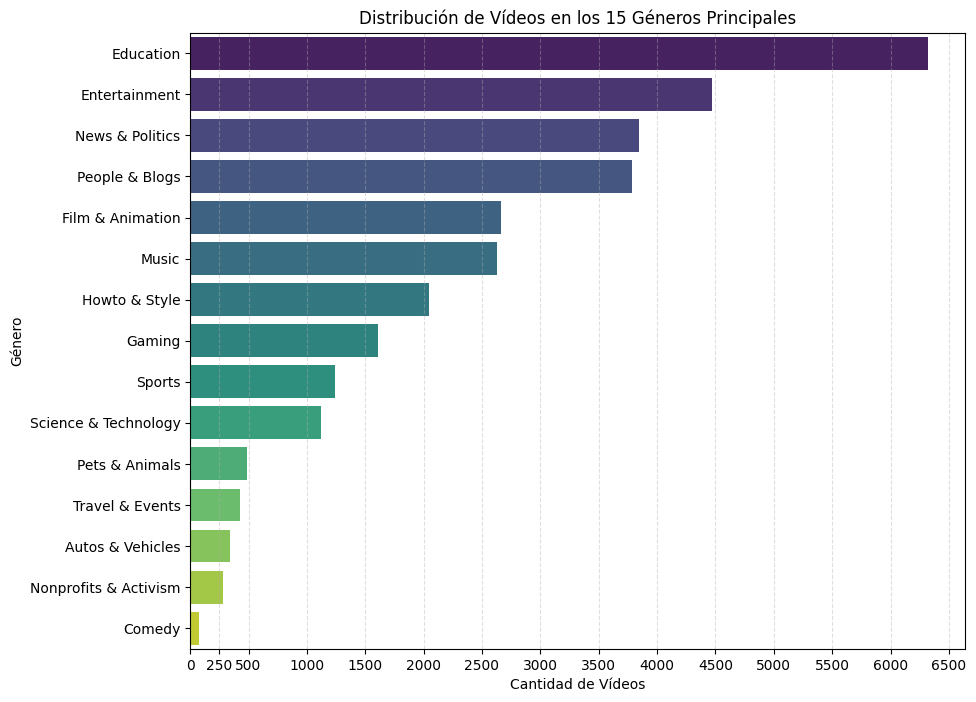

In [8]:
#Frecuencias
generos_nombres = list(diccionario_generos.keys())
frecuencias = [len(df) for df in diccionario_generos.values()]

#Ordenamos
datos_ordenados = pd.Series(frecuencias, index=generos_nombres).sort_values(ascending=False)

#Grafica
plt.figure(figsize=(10, 8))
sns.barplot(x=datos_ordenados.values, y=datos_ordenados.index, palette='viridis')
#Ticks
max_frecuencia = datos_ordenados.max()
tus_ticks = [0, 250, 500]

paso_automatico = 200 if max_frecuencia < 2000 else 500
ticks_automaticos = list(range(0, int(max_frecuencia) + paso_automatico, paso_automatico))

ticks_finales = sorted(list(set(tus_ticks + ticks_automaticos)))
plt.xticks(ticks_finales)


plt.title("Distribución de Vídeos en los 15 Géneros Principales")
plt.xlabel("Cantidad de Vídeos")
plt.ylabel("Género")
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

Nos quedamos con 15. De esos 15 vamos a trabajar con los 8 mas frecuentes.

In [9]:
claves_ordenadas = sorted(diccionario_generos, key=lambda k: len(diccionario_generos[k]), reverse=True)

generos_seleccionados = claves_ordenadas[:8]

diccionario_top = {k: diccionario_generos[k] for k in generos_seleccionados}

print(f"Top 8 generos mas frecuentes: {list(diccionario_top.keys())}")

Top 8 generos mas frecuentes: ['Education', 'Entertainment', 'News & Politics', 'People & Blogs', 'Film & Animation', 'Music', 'Howto & Style', 'Gaming']


Filtramos también los df en funcion a si tienen subtitulos o no

In [10]:
diccionario_subs = {
    clave: df[df['Subtitulos'].apply(lambda x: isinstance(x, str) and len(x.strip()) > 0)].copy() 
    for clave, df in diccionario_top.items()
}

for clave in diccionario_subs:
    print(f"{clave}: {len(diccionario_subs[clave])} vídeos con subtítulos.")

Education: 6323 vídeos con subtítulos.
Entertainment: 4470 vídeos con subtítulos.
News & Politics: 3845 vídeos con subtítulos.
People & Blogs: 3784 vídeos con subtítulos.
Film & Animation: 2666 vídeos con subtítulos.
Music: 2632 vídeos con subtítulos.
Howto & Style: 2049 vídeos con subtítulos.
Gaming: 1610 vídeos con subtítulos.


# Análisis no textual

## Duracion

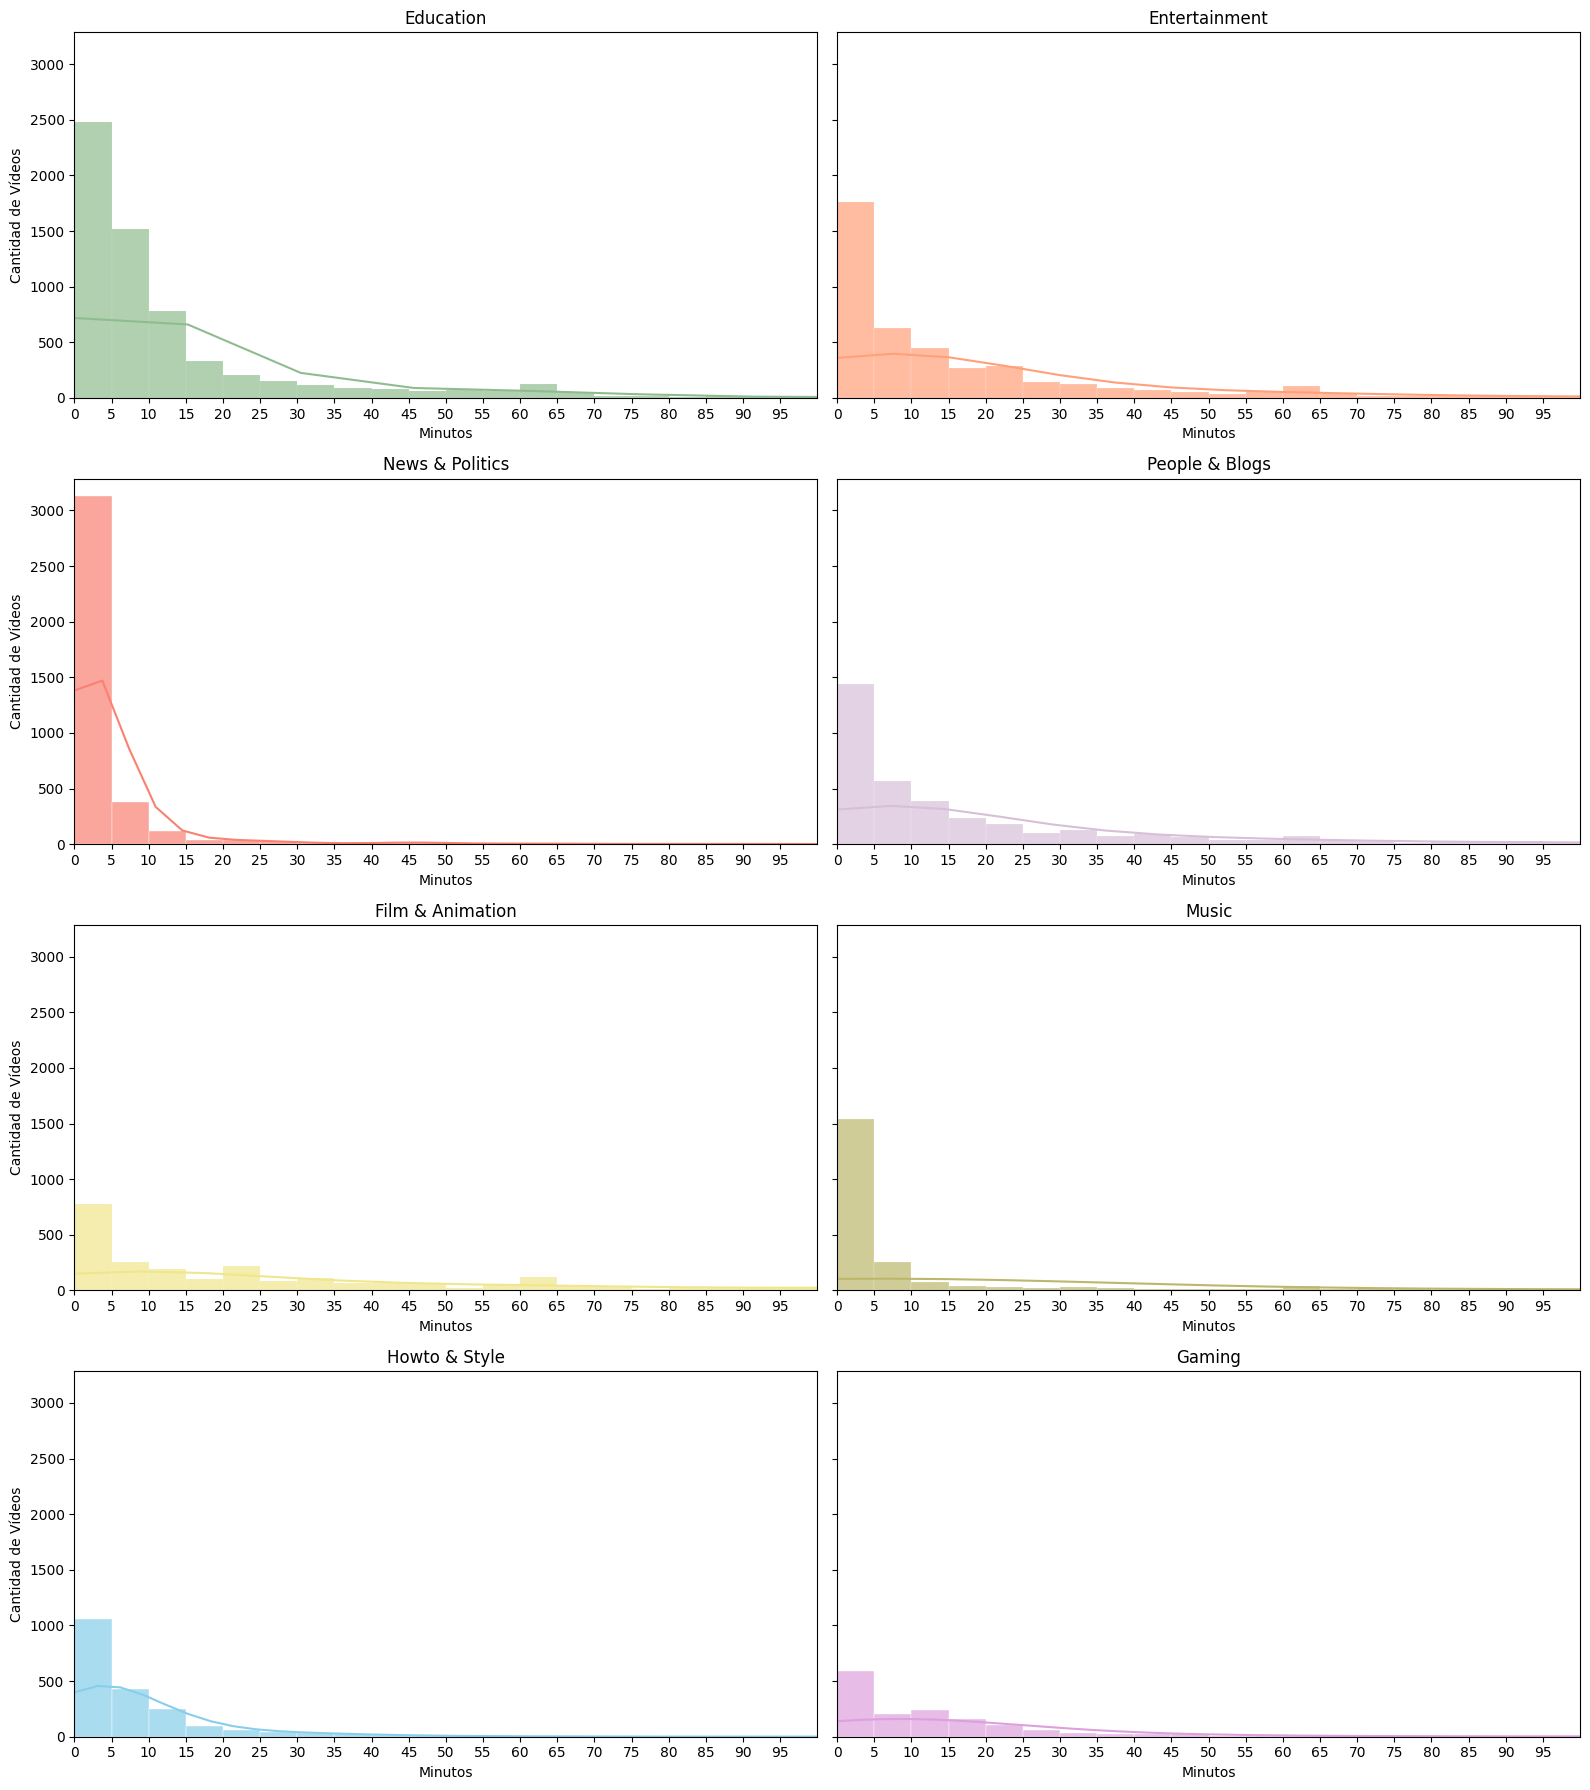

In [11]:
# Configuración
fig, ax = plt.subplots(4, 2, figsize=(16, 18), sharey=True)

ax = ax.flatten()
colores = ['darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki', 'skyblue', 'plum']

for i, clave in zip(range(0,8), diccionario_top):
    utils.graficar_histograma_duracion(diccionario_top[clave], clave, ax[i], colores[i])

plt.tight_layout()
plt.show()

**COMPLETAR**

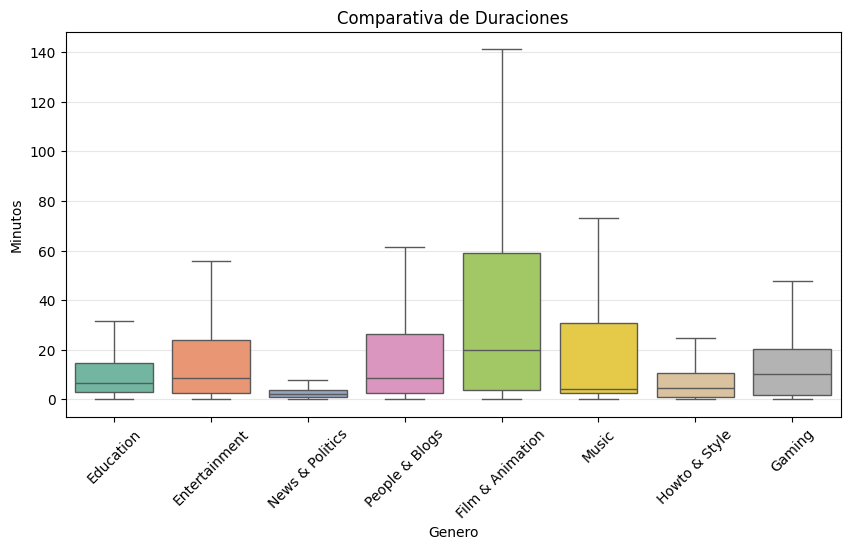

In [12]:
df_grafica = pd.concat([
    df.assign(Genero=clave) for clave, df in diccionario_top.items()
])

plt.figure(figsize=(10, 5))
sns.boxplot(x='Genero', y='Duracion', data=df_grafica, palette='Set2', showfliers=False)  

plt.xticks(rotation=45)
plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.grid(axis = "y", alpha = 0.3)
plt.show()

## Densidad de habla

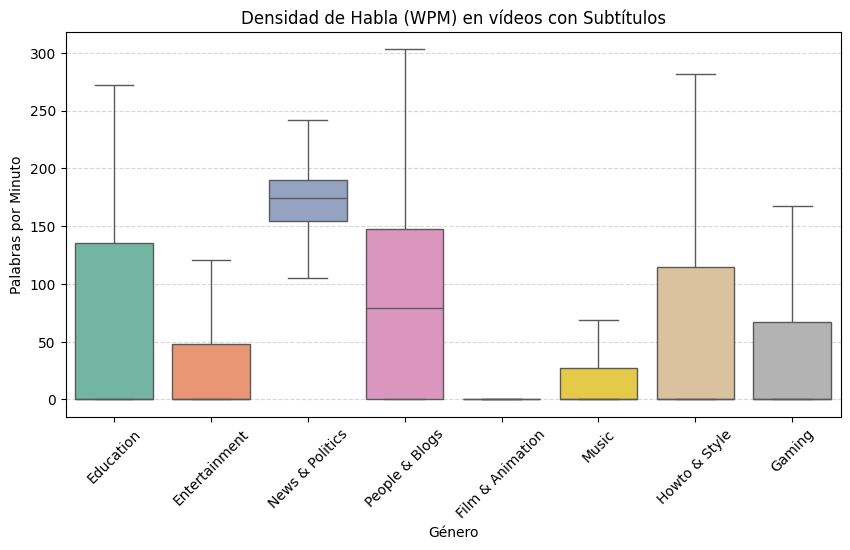

In [13]:
df_grafica_subs = pd.concat([
    df.assign(Genero=clave) for clave, df in diccionario_subs.items()
])

plt.figure(figsize=(10, 5))

#No mostramos los outliers para que se vea más limpio
sns.boxplot(x='Genero', y='Palabras_Por_Minuto', data=df_grafica_subs, palette='Set2', showfliers=False)


plt.title('Densidad de Habla (WPM) en vídeos con Subtítulos')
plt.xlabel('Género')
plt.ylabel('Palabras por Minuto')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Analisis Textual

## Título

In [14]:
diccionario_tf_titulos = {}

for clave, df_genero in diccionario_top.items():
    diccionario_tf_titulos[clave] = utils.tfidf_ngrams_titles(df_genero, "Titulo")


In [15]:
common_terms = utils.common_terms_dictionary(diccionario_tf_titulos, "Titulo")

common_terms.sort_values("Score_Std", ascending=False).head(20)

,Titulo,Score_Education,Score_Entertainment,Score_News & Politics,Score_People & Blogs,Score_Film & Animation,Score_Music,Score_Howto & Style,Score_Gaming,Score_Std,Score_Total
0,kids,157.078476,101.974670,4.617376,26.673143,68.784540,29.002425,16.790025,1.599017,54.778636,406.519673
1,learn,66.426043,18.459963,1.183948,9.354771,11.690796,6.112594,7.229196,1.990696,21.374806,122.448008
2,song,58.468155,23.990555,0.881952,7.312621,16.338878,37.186217,1.505609,2.023670,20.623377,147.707657
10,episode,21.991227,34.459076,1.265999,15.308845,38.285343,2.626615,3.703394,10.656220,14.389660,128.296720
161,official,1.769633,14.573524,2.145635,6.259549,16.162272,42.203621,1.049902,2.580586,13.983922,86.744723
4,video,28.616002,21.812479,11.262500,17.012738,13.066814,42.538190,7.388008,4.742255,12.465385,146.438986
3,2026,38.868654,19.662771,31.219201,33.855110,4.787276,22.647679,13.167086,8.775537,12.328932,172.983314
14,make,20.395924,13.647176,5.777053,14.863338,6.140162,1.724946,35.327796,6.039224,10.901689,103.915618
26,new,14.600471,23.994932,40.868457,19.437536,21.062584,9.471372,12.543351,20.308083,9.621013,162.286785
7,vs,24.630684,22.581669,2.922576,19.107317,11.923691,6.311321,11.192687,27.716290,9.016053,126.386236


Interpretación: El score indica qué palabras tienen puntuaciones muy diferentes entre los géneros (si el valor es alto) y cuáles aparecen en todos.
El score global nos dice cómo de significativas pueden ser las palabras.

Ahora vamos a comparar las palabras que aparecen exclusivamente en un genero de entre dos que son pueden tener solapaciones.

In [16]:
entertainment_only, gaming_only = utils.exclusive_terms(diccionario_tf_titulos["Entertainment"], 
    diccionario_tf_titulos["Gaming"], "Titulo")

print("Gaming")
print(gaming_only.head(5))
print("Entertainment")
print(entertainment_only.head(5))

Gaming
             Titulo     Score
2440    walkthrough  7.233148
1494            mod  7.012912
1500           mode  6.381914
952   geometry dash  6.170012
951        geometry  6.170012
Entertainment
        Titulo      Score
775     blippi  36.257273
1150  cartoons  30.443450
6053     songs  29.466433
6943    videos  25.358972
1136   cartoon  23.417867


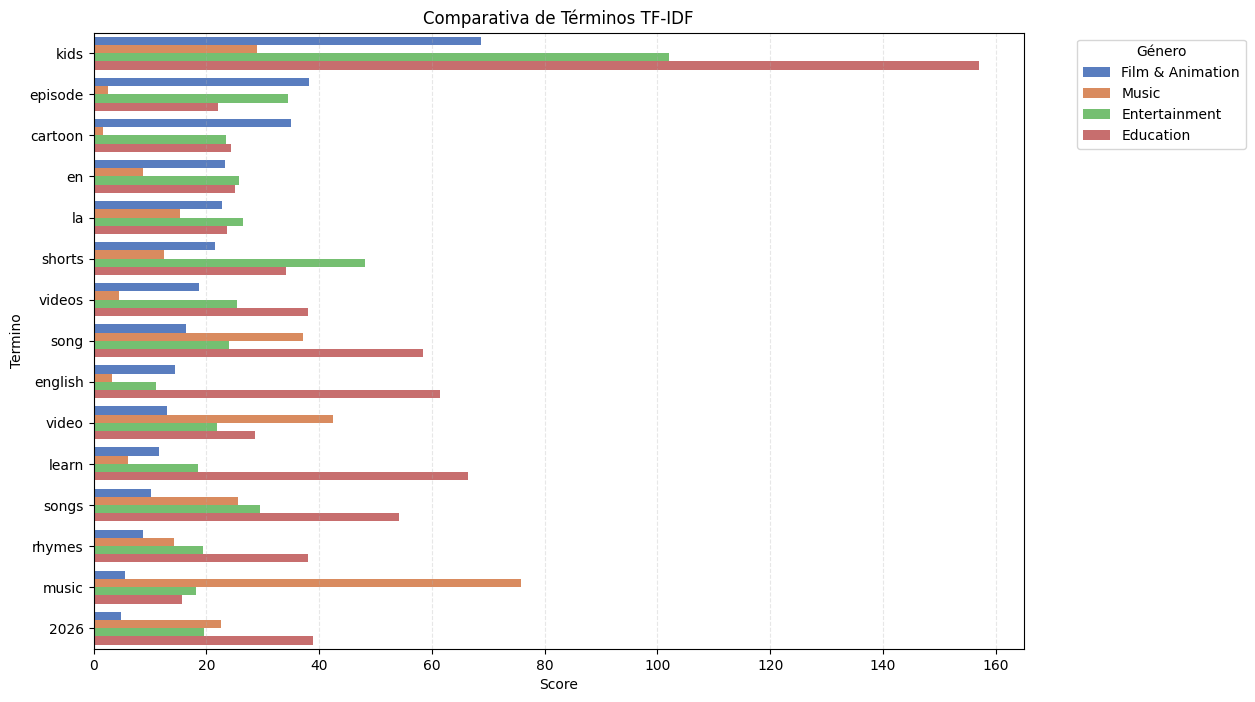

In [17]:
#Seleccionamos 4 generos
generos_a_comparar = ['Film & Animation', 'Music', 'Entertainment', 'Education']

plt.figure(figsize=(12, 8))
utils.comparativa_terminos(generos_a_comparar, diccionario_tf_titulos)
plt.show()

In [18]:
#BERTOPIC SOLUCIONAR
topic_model_titulo, df_bertopic_titulo, temas_bertopic_titulo = utils.analizar_bertopic_dict(diccionario_top, "Titulo")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [19]:
dicc_bertopic_titulo = utils.division_generos(df_bertopic_titulo)
claves_ordenadas = sorted(dicc_bertopic_titulo, key=lambda k: len(dicc_bertopic_titulo[k]), reverse=True)

#Volvemos a filtrar el top 8
generos_seleccionados = claves_ordenadas[:8]
diccionario_top_bertopic_titulo = {k: dicc_bertopic_titulo[k] for k in generos_seleccionados}

for clave in diccionario_top_bertopic_titulo:
    print(f'Size of {clave, len(diccionario_top_bertopic_titulo[clave])}')


Size of ('Education', 6323)
Size of ('Entertainment', 4470)
Size of ('News & Politics', 3845)
Size of ('People & Blogs', 3784)
Size of ('Film & Animation', 2666)
Size of ('Music', 2632)
Size of ('Howto & Style', 2049)
Size of ('Gaming', 1610)


<Figure size 1000x600 with 0 Axes>

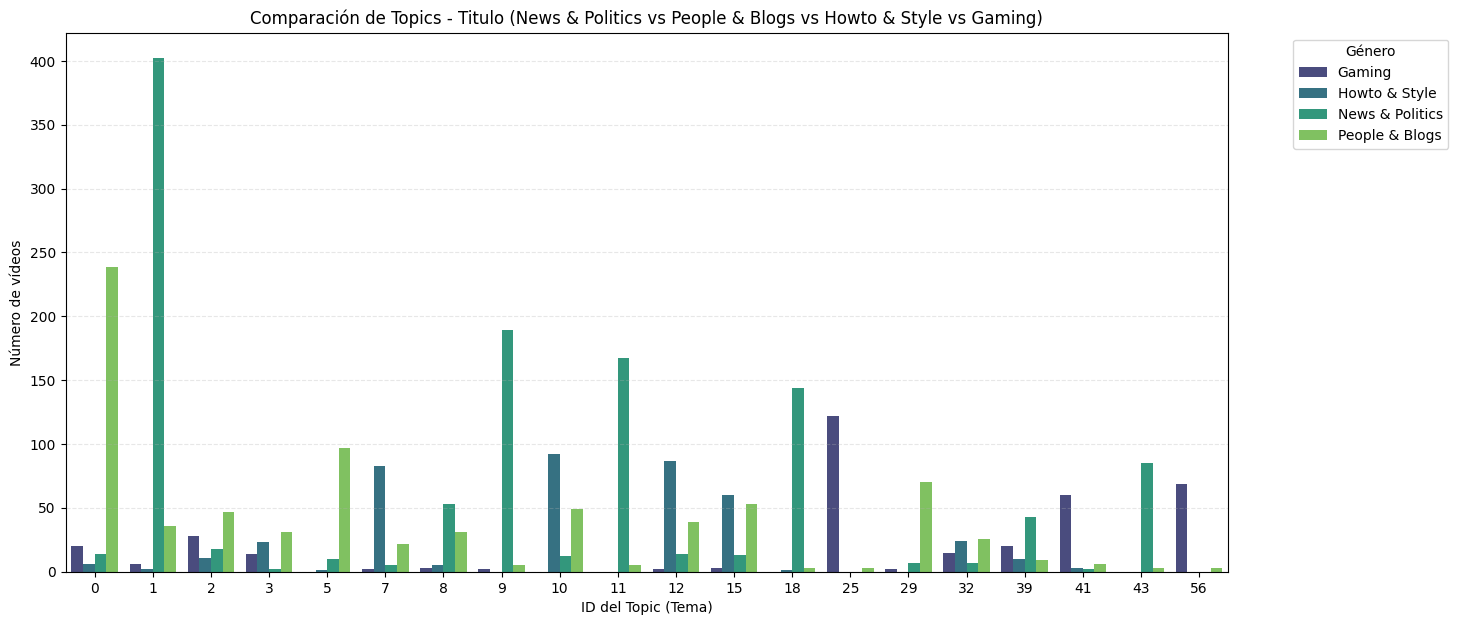

In [20]:
generos_a_comparar = ["News & Politics", "People & Blogs", "Howto & Style", "Gaming"]

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_titulo, generos_a_comparar, "Titulo")
plt.show()

## Titulo canal


In [21]:
diccionario_tf_titulo_canal = {}

for clave, df_genero in diccionario_top.items():
    diccionario_tf_titulo_canal[clave] = utils.tfidf_ngrams_titles(df_genero, "Titulo_canal")

**Terminos comunes**

In [22]:
common_terms = utils.common_terms_dictionary(diccionario_tf_titulo_canal, "Titulo_canal")

common_terms.sort_values("Score_Std", ascending=False).head(20)

,Titulo_canal,Score_Education,Score_Entertainment,Score_News & Politics,Score_People & Blogs,Score_Film & Animation,Score_Music,Score_Howto & Style,Score_Gaming,Score_Std,Score_Total
0,tv,40.756535,38.604934,64.844596,20.991297,20.414145,11.759065,9.774798,1.789366,20.681041,208.934736
1,channel,24.825330,34.821097,32.992012,11.615658,56.062647,20.146429,6.000000,5.876533,17.101856,192.339705
2,world,19.484479,31.966750,3.501685,13.115040,8.423990,2.991656,7.770555,3.000000,10.119660,90.254155
3,family,3.430555,19.886735,5.609715,19.332639,8.590308,1.395529,9.257900,0.891327,7.464060,68.394709


**Terminos exclusivos**

In [23]:
#Entertainment vs Films & Animation
entertainment_only, films_only = utils.exclusive_terms(diccionario_tf_titulo_canal["Entertainment"], 
    diccionario_tf_titulo_canal["Film & Animation"], "Titulo_canal")

print("Film & Animation")
print(films_only.head(5))
print("Entertainment")
print(entertainment_only.head(5))

Film & Animation
     Titulo_canal      Score
557        fixies  28.000000
1110        peppa  25.063095
1139          pig  24.988550
1113    peppa pig  23.405158
750        katuri  21.000000
Entertainment
     Titulo_canal      Score
1342         lego  36.187759
2335         toys  36.021025
259        blippi  35.228124
1560      mrbeast  34.000000
1358         like  32.133372


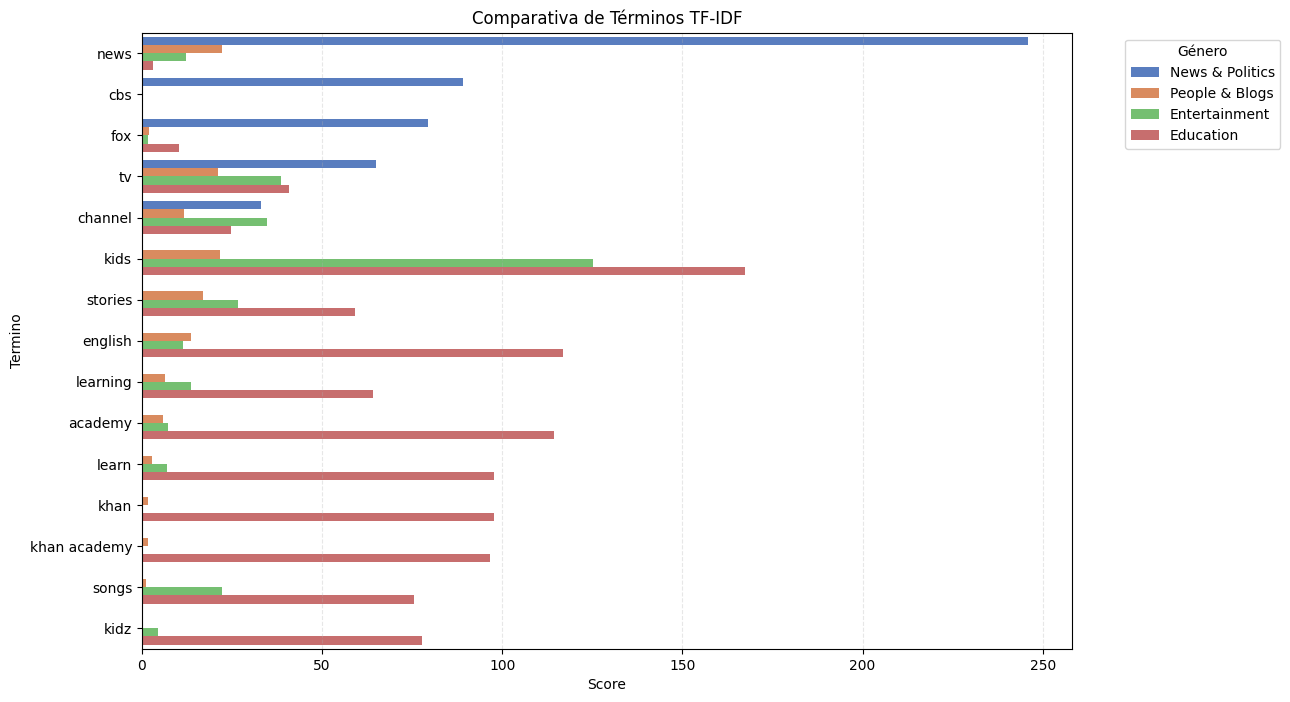

In [24]:
#Seleccionamos 4 generos
generos_a_comparar = ["News & Politics", "People & Blogs", 'Entertainment', 'Education']

plt.figure(figsize=(12, 8))
utils.comparativa_terminos(generos_a_comparar, diccionario_tf_titulo_canal)
plt.show()

In [25]:
topic_model_titulo_canal, df_bertopic_titulo_canal, temas_bertopic_titulo_canal = utils.analizar_bertopic_dict(diccionario_top, "Titulo_canal")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
dicc_bertopic_titulo_canal = utils.division_generos(df_bertopic_titulo_canal)
claves_ordenadas = sorted(dicc_bertopic_titulo_canal, key=lambda k: len(dicc_bertopic_titulo_canal[k]), reverse=True)

#Volvemos a filtrar el top 8
generos_seleccionados = claves_ordenadas[:8]
diccionario_top_bertopic_titulo_canal = {k: dicc_bertopic_titulo_canal[k] for k in generos_seleccionados}

for clave in diccionario_top_bertopic_titulo_canal:
    print(f'Size of {clave, len(diccionario_top_bertopic_titulo_canal[clave])}')


Size of ('Education', 6323)
Size of ('Entertainment', 4470)
Size of ('News & Politics', 3845)
Size of ('People & Blogs', 3784)
Size of ('Film & Animation', 2666)
Size of ('Music', 2632)
Size of ('Howto & Style', 2049)
Size of ('Gaming', 1610)


<Figure size 1000x600 with 0 Axes>

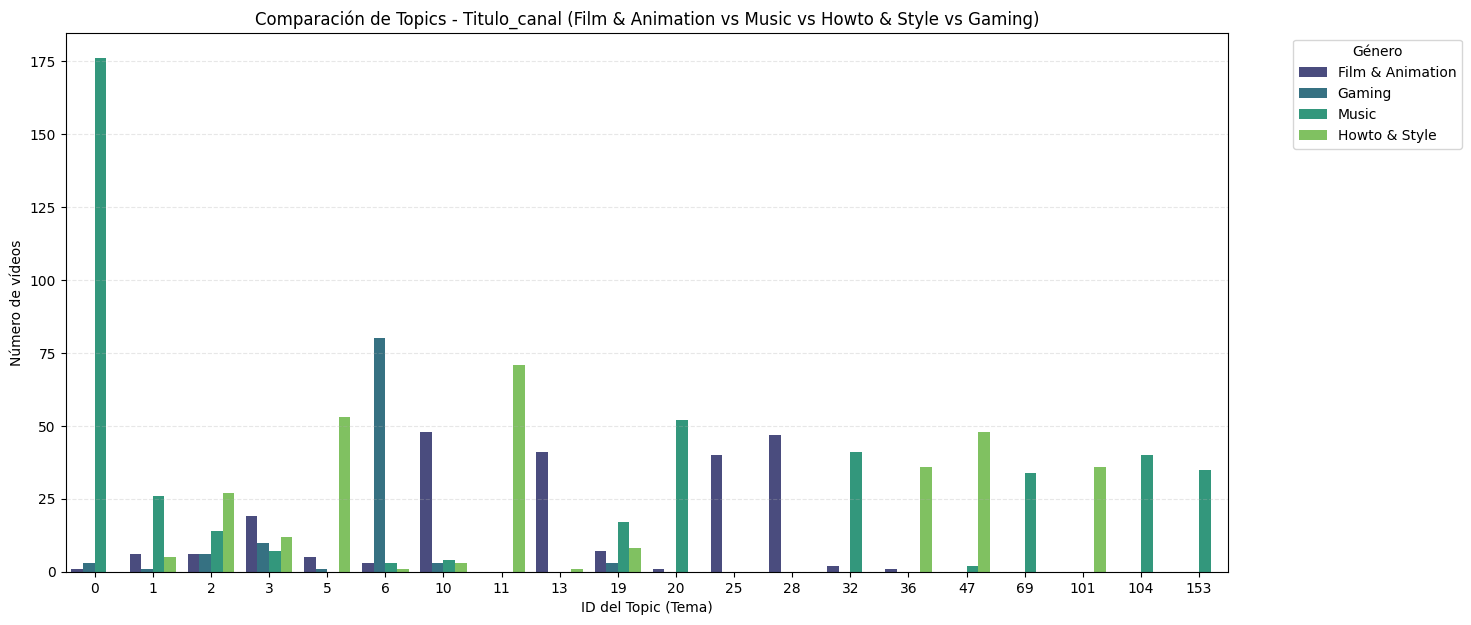

In [27]:
generos_a_comparar = ['Film & Animation', 'Music', "Howto & Style", "Gaming"]

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_titulo_canal, generos_a_comparar, "Titulo_canal")
plt.show()

In [28]:
topic_info = topic_model_titulo_canal.get_topic_info()
topic_info.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5011,-1_university_tinga_purr_college,"[university, tinga, purr, college, cry, tiny, ...","[SleepTube - Hypnotic Relaxation, SleepTube - ..."
1,0,229,0_music_engraver_arezzo_musicclubkids,"[music, engraver, arezzo, musicclubkids, campo...","[Arezzo - Sheet Music engraver, Arezzo - Sheet..."
2,1,182,1_wisdom_prayers_god_faith,"[wisdom, prayers, god, faith, church, holy, bi...","[Prayers, Cross of God Church, United Church o..."
3,2,140,2_tamara_amy_linda_dreamland,"[tamara, amy, linda, dreamland, deen, allie, s...","[Platos Fáciles con Tamara, Platos Fáciles con..."
4,3,139,3_badanamu_sorcier_pas_est,"[badanamu, sorcier, pas, est, guess, tieu, go,...","[C'est pas sorcier, C'est pas sorcier, C'est p..."
5,4,125,4_health_doctor_dr_healthtree,"[health, doctor, dr, healthtree, bolt, seuss, ...","[Health Tips, Doctors' Circle World's Largest ..."
6,5,111,5_nhuan_calligraphy_art_painting,"[nhuan, calligraphy, art, painting, dao, craft...","[Nhuan Dao Calligraphy, Nhuan Dao Calligraphy,..."
7,6,107,6_gaming_gamer_apkno1_gamingfamily,"[gaming, gamer, apkno1, gamingfamily, jkrew, k...","[APKNo1 - Gaming Channel, APKNo1 - Gaming Chan..."
8,7,106,7_language_singsing_tree_veronika,"[language, singsing, tree, veronika, stat, sho...","[Veronika's Language Diaries, Veronika's Langu..."
9,8,105,8_morphle_tv_bud_wifr,"[morphle, tv, bud, wifr, air, akili, vintage, ...","[Air Bud TV, Air Bud TV, Air Bud TV]"


## Tags


In [29]:
diccionario_tf_tags = {}
diccionario_frec_tags = {}
for clave in diccionario_top:
    diccionario_tf_tags[clave] = utils.tfidf_tags(diccionario_top[clave]) 
    diccionario_frec_tags[clave] = utils.frecuencia_tags(diccionario_top[clave])


In [30]:
common_terms = utils.common_terms_dictionary(diccionario_frec_tags, "Tag")
common_terms.sort_values("Frecuencia_Education", ascending=False).head(20)

,Tag,Frecuencia_Education,Frecuencia_Entertainment,Frecuencia_News & Politics,Frecuencia_People & Blogs,Frecuencia_Film & Animation,Frecuencia_Music,Frecuencia_Howto & Style,Frecuencia_Gaming,Score_Std,Score_Total
0,,890,681,846,1308,214,278,388,307,384.400461,4912
1,kids,458,411,1,37,269,86,41,10,187.501190,1313
2,preschool,314,212,1,7,165,46,9,2,120.459833,756
3,learning,283,145,1,7,45,12,43,2,99.287102,538
4,children,281,229,1,16,72,40,8,1,110.853829,648
5,videos for kids,187,206,1,11,93,34,1,1,85.931451,534
6,animation,177,157,1,24,402,24,2,8,141.320242,795
7,family,88,155,2,42,64,26,5,6,52.850193,388
8,video,68,49,354,8,15,29,16,26,116.189424,565
9,videos,53,68,1,2,8,1,11,2,26.628395,146


Mirar que significa yt:cc = on

In [31]:
common_terms = utils.common_terms_dictionary(diccionario_tf_tags, "Tag")

common_terms.sort_values("Score_Std", ascending=False).head(15)

,Tag,Score_Education,Score_Entertainment,Score_News & Politics,Score_People & Blogs,Score_Film & Animation,Score_Music,Score_Howto & Style,Score_Gaming,Score_Std,Score_Total
0,kids,4369.368586,3275.278975,7.964023,372.800206,2143.849601,762.682123,204.486316,46.217061,1671.105472,11182.646890
16,music,363.231701,402.617838,9.631447,334.365711,110.886883,2330.703951,10.948955,27.414866,778.317382,3589.801353
101,news,73.443243,142.306992,2054.847056,136.909158,1.889998,2.339615,1.432267,35.956211,708.954290,2449.124540
1,videos,1538.617211,1114.051670,16.961826,105.776606,543.495445,194.792378,95.818195,42.616720,572.837845,3652.130051
2,english,1417.134042,268.208685,14.331369,100.433510,563.248591,44.824681,14.826128,15.198849,488.013487,2438.205855
3,learning,1317.417753,489.243819,1.453477,46.195823,229.854022,61.740042,81.558772,3.331526,450.132827,2230.795235
4,children,1122.474967,672.877831,6.307545,61.422863,442.708377,255.977430,19.114575,4.803839,404.034712,2585.687427
5,learn,1117.792997,351.832094,4.464711,68.618473,125.404453,77.393471,86.724870,2.537233,375.389752,1834.768302
6,song,955.365827,423.420945,1.184945,52.689518,408.055595,553.349347,7.738185,10.090001,346.513039,2411.894363
7,baby,882.403015,644.722454,5.171448,99.258578,309.802436,180.247497,61.437040,2.898300,324.948045,2185.940767


In [32]:
politics_only, education_only = utils.exclusive_terms(diccionario_frec_tags["News & Politics"], 
    diccionario_frec_tags["Education"], "Tag")

print("News & Politics")
print(politics_only.head(5))
print("Education")
print(education_only.head(5))

News & Politics
             Tag  Frecuencia
3     local news         221
23        news ]         215
24       [ local         171
212      local ]          92
828  syndication          49
Education
                 Tag  Frecuencia
536   nursery rhymes         400
623      kids videos         298
1094        for kids         272
534       kids songs         246
544     kindergarten         239


<Figure size 1000x600 with 0 Axes>

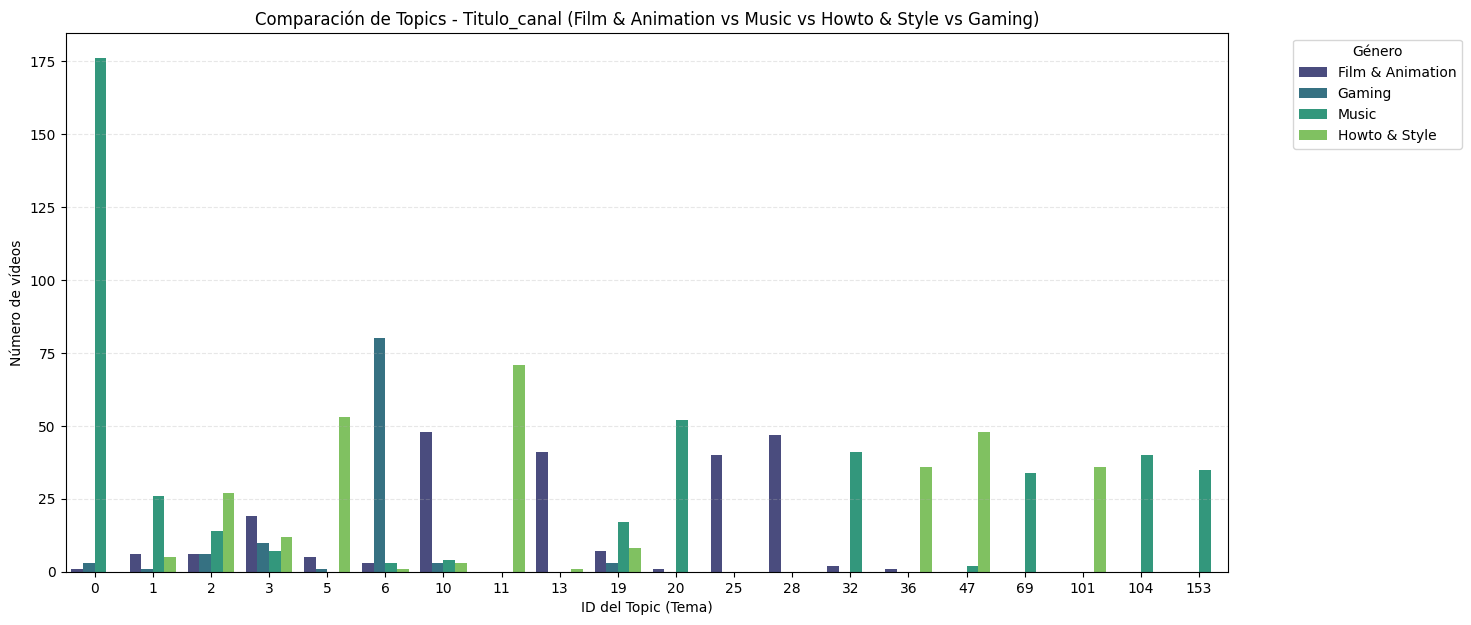

In [33]:
generos_a_comparar = ['Film & Animation', 'Music', "Howto & Style", "Gaming"]

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_titulo_canal, generos_a_comparar, "Titulo_canal")
plt.show()

## Descripción

In [34]:

topic_model_descripcion, df_bertopic_descripcion, temas_bertopic_descripcion  = utils.analizar_bertopic_dict(diccionario_top, "Descripcion")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [35]:
dicc_bertopic_descripcion= utils.division_generos(df_bertopic_descripcion)
claves_ordenadas = sorted(dicc_bertopic_descripcion, key=lambda k: len(dicc_bertopic_descripcion[k]), reverse=True)

#Volvemos a filtrar el top 8
generos_seleccionados = claves_ordenadas[:8]
diccionario_top_bertopic_descripcion = {k: dicc_bertopic_descripcion[k] for k in generos_seleccionados}

for clave in diccionario_top_bertopic_descripcion:
    print(f'Size of {clave, len(diccionario_top_bertopic_descripcion[clave])}')


Size of ('Education', 6161)
Size of ('Entertainment', 4221)
Size of ('News & Politics', 3822)
Size of ('People & Blogs', 3575)
Size of ('Film & Animation', 2647)
Size of ('Music', 2574)
Size of ('Howto & Style', 1956)
Size of ('Gaming', 1558)


<Figure size 1000x600 with 0 Axes>

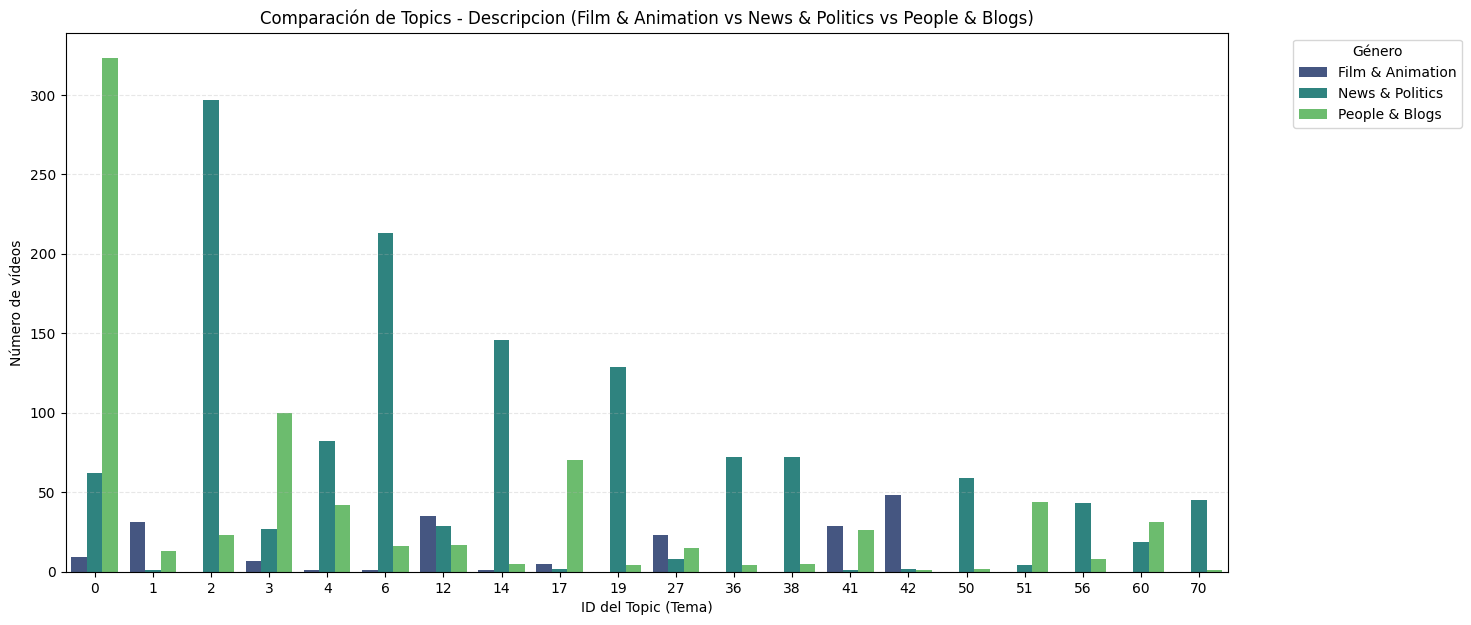

In [36]:
generos_a_comparar = ['Film & Animation', "News & Politics", "People & Blogs"]

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_descripcion, generos_a_comparar, "Descripcion")
plt.show()


## Subtítulos

In [37]:

topic_model_subtitulos, df_bertopic_subtitulos, temas_bertopic_subtitulos  = utils.analizar_bertopic_dict(diccionario_top, "Descripcion")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
dicc_bertopic_subtitulos= utils.division_generos(df_bertopic_subtitulos)
claves_ordenadas = sorted(dicc_bertopic_subtitulos, key=lambda k: len(dicc_bertopic_subtitulos[k]), reverse=True)

#Volvemos a filtrar el top 8
generos_seleccionados = claves_ordenadas[:8]
diccionario_top_bertopic_subtitulos = {k: dicc_bertopic_subtitulos[k] for k in generos_seleccionados}

for clave in diccionario_top_bertopic_subtitulos:
    print(f'Size of {clave, len(diccionario_top_bertopic_subtitulos[clave])}')


Size of ('Education', 6161)
Size of ('Entertainment', 4221)
Size of ('News & Politics', 3822)
Size of ('People & Blogs', 3575)
Size of ('Film & Animation', 2647)
Size of ('Music', 2574)
Size of ('Howto & Style', 1956)
Size of ('Gaming', 1558)


<Figure size 1000x600 with 0 Axes>

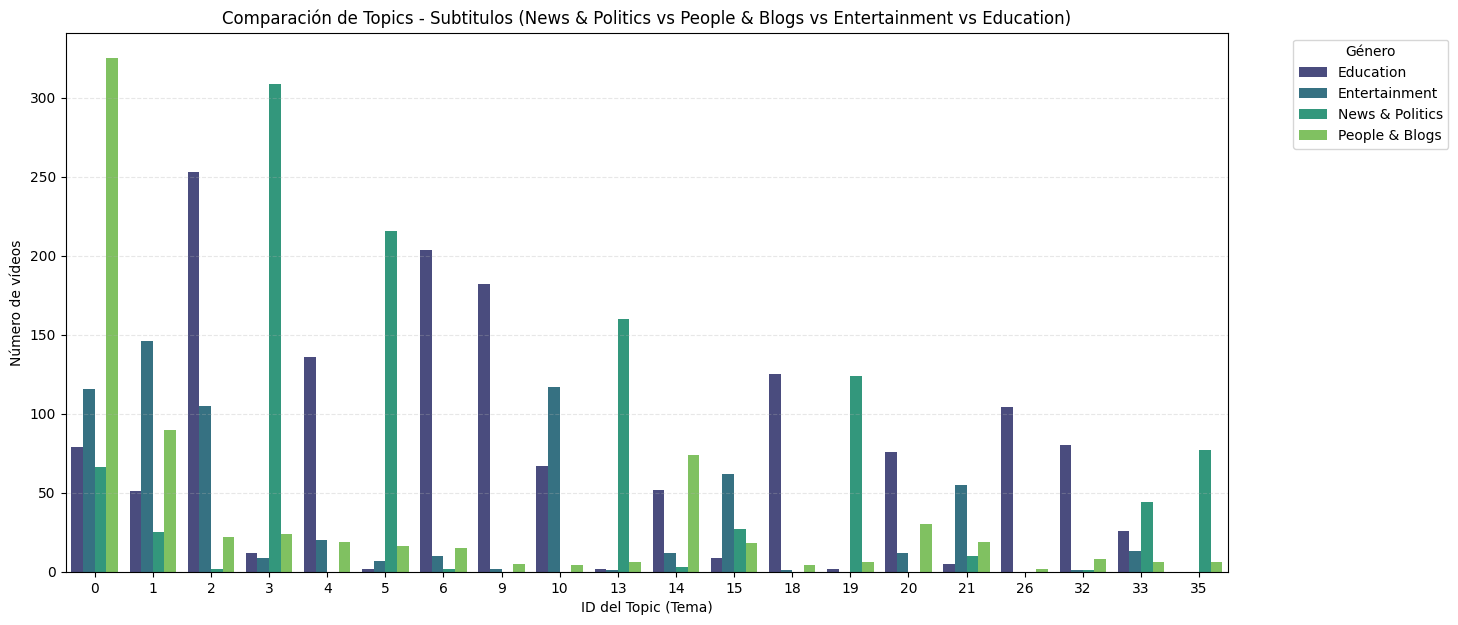

In [39]:
generos_a_comparar = ["News & Politics", "People & Blogs", 'Entertainment', 'Education']

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_subtitulos, generos_a_comparar, "Subtitulos")
plt.show()